<a href="https://colab.research.google.com/github/paulishita14-netizen/flyrank-ml-internship1/blob/main/02_your_first_readable_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/paulishita14-netizen/flyrank-ml-internship1/blob/main/notebooks/02_your_first_readable_model.ipynb?flush_cache=true)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [ ]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
16751,61678,194,19.7,0.15,down
16514,59472,194,24.8,0.13,down
7021,25715,194,22.2,0.23,down
21268,13299,193,10.5,0.49,down
11489,7812,194,39.0,0.01,down
12045,7558,193,17.9,0.20,down
698,4590,194,31.0,0.00,down
5327,4556,194,16.4,0.33,down
26810,4429,194,25.3,0.38,down
20837,1697,193,15.8,0.12,down


We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [ ]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0



That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [ ]:
tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.550
Precision@50:  hand rule 0.680   vs   tree 0.600


Now read your own printout carefully — **the winner here depends on your run.** A depth-2 tree can only give four different scores (one per leaf), so the "top 50" is mostly one big block of tied pages, and different library versions break those ties differently. On some stacks the tree wins at Precision@50; on others the hand rule holds both. **Both results are real.** The stable lesson: a sharp human rule can be excellent at the very top of the list; a model's advantage — when it shows up — appears deeper, where simple rules run out of signal; and any comparison built on heavily tied scores is fragile. Saying exactly what YOUR run shows — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [ ]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

'Leaky' tree Precision@50: 1.000  <- looks amazing
|--- trend_pct <= -20.05
|   |--- word_count <= 212.00
|   |   |--- class: 1
|   |--- word_count >  212.00
|   |   |--- class: 1
|--- trend_pct >  -20.05
|   |--- trend_pct <= -19.95
|   |   |--- class: 0
|   |--- trend_pct >  -19.95
|   |   |--- class: 0



The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

In [ ]:
import pandas as pd, numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text

# --- Start of self-contained df loading logic for robustness ---
if 'df' not in locals():
    import os, sys, subprocess

    IN_COLAB = "google.colab" in sys.modules
    REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
    REPO_DIR = "flyrank-ml-internship-starter"

    # Ensure the repository is cloned and the working directory is correct.
    # This logic is adapted from the setup cell (5534b8d2) to make this cell runnable independently.
    if IN_COLAB:
        if not os.path.isdir(REPO_DIR):
            print(f"Cloning {REPO_URL} into {REPO_DIR}...")
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)

        # Check current working directory. If it's not the repo directory, change to it.
        if os.path.basename(os.getcwd()) != REPO_DIR:
            print(f"Changing current directory to {REPO_DIR}...")
            os.chdir(REPO_DIR)
    elif os.path.basename(os.getcwd()) == "notebooks":
        # Handle local execution from 'notebooks' subdirectory
        print("Changing directory to parent for local execution...")
        os.chdir("..")

    # Now, attempt to read the CSV again from the assumed correct CWD.
    try:
        df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
        df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
        print("DataFrame 'df' loaded successfully after re-initialization.")
    except FileNotFoundError:
        print(f"Error: 'data/raw/content_refresh_anonymized.csv' not found. Current working directory: {os.getcwd()}")
        print("Please ensure the repository is correctly cloned and the working directory is set.")
        raise # Re-raise the error to stop execution if fundamental data loading fails.
    except Exception as e:
        print(f"An unexpected error occurred during df loading: {e}")
        raise
# --- End of self-contained df loading logic ---

# Re-define precision_at_k function (from cell 4f2a651a)
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

# Re-define y (from cell 4f2a651a)
y = df["is_declining_label"].values

# Re-define features and X (from cell d941a5dc)
features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

print('--- Experiment 1: max_depth = 3 ---')
tree_depth3 = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree_depth3.fit(X, y)

print(export_text(tree_depth3, feature_names=features))

tree_score_depth3 = tree_depth3.predict_proba(X)[:, 1]
for k in (20, 50):
    tr = precision_at_k(tree_score_depth3, y, k)
    print(f"Precision@{k}:  tree_depth3 {tr:.3f}")

print('\n--- Experiment 2: max_depth = 4 ---')
tree_depth4 = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
tree_depth4.fit(X, y)

print(export_text(tree_depth4, feature_names=features))

tree_score_depth4 = tree_depth4.predict_proba(X)[:, 1]
for k in (20, 50):
    tr = precision_at_k(tree_score_depth4, y, k)
    print(f"Precision@{k}:  tree_depth4 {tr:.3f}")

print('\n--- Experiment 3: Swap features (drop impressions_90d, add engagement_rate) ---')
# Assuming 'engagement_rate' is a new feature that needs to be added to df
# For this experiment, let's create a dummy 'engagement_rate' if it doesn't exist
# In a real scenario, you would load or derive this feature properly
if 'engagement_rate' not in df.columns:
    df['engagement_rate'] = df['ctr'] * 100 # Example dummy calculation

features_new = [f for f in features if f != "impressions_90d"] + ["engagement_rate"]
X_new = df[features_new].replace([np.inf, -np.inf], np.nan).fillna(0)

tree_new_features = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree_new_features.fit(X_new, y)

print(export_text(tree_new_features, feature_names=features_new))

tree_score_new_features = tree_new_features.predict_proba(X_new)[:, 1]
for k in (20, 50):
    tr = precision_at_k(tree_score_new_features, y, k)
    print(f"Precision@{k}:  tree_new_features {tr:.3f}")

--- Experiment 1: max_depth = 3 ---
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.33
|   |   |   |--- class: 1
|   |   |--- ctr >  0.33
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 25.15
|   |   |   |--- class: 0
|   |   |--- avg_position >  25.15
|   |   |   |--- class: 0

Precision@20:  tree_depth3 0.700
Precision@50:  tree_depth3 0.720

--- Experiment 2: max_depth = 4 ---
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- word_count <= 687.00
|   |   |   |   |--- class: 0
|   |   |   |--- word_co

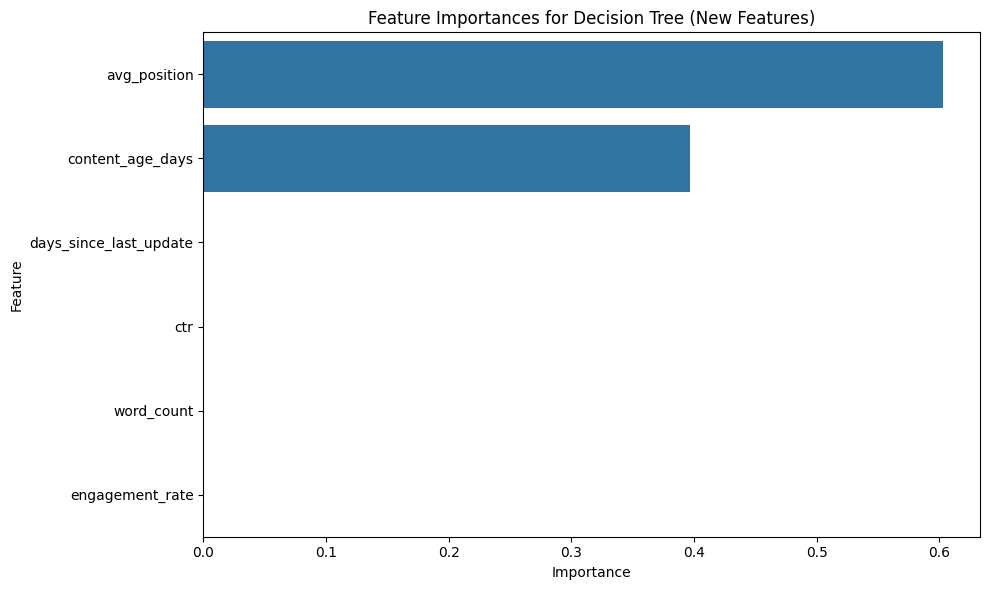

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the tree_new_features model
feature_importances = tree_new_features.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features_new,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for Decision Tree (New Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Re-run comparison with a train/test split (Client-Holdout Validation)

In [ ]:
from sklearn.model_selection import train_test_split

# Get unique client IDs
client_ids = df['client_id'].unique()

# Split client IDs into training and testing sets
# Using a fixed random state for reproducibility
train_clients, test_clients = train_test_split(client_ids, test_size=0.2, random_state=42)

# Create masks for the DataFrame based on client IDs
train_mask = df['client_id'].isin(train_clients)
test_mask = df['client_id'].isin(test_clients)

# Split the data into training and testing sets
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Total data points: {len(df)}")
print(f"Training data points (clients: {len(train_clients)}): {len(X_train)}")
print(f"Testing data points (clients: {len(test_clients)}): {len(X_test)}")
print(f"Train declining rate: {y_train.mean():.3f}")
print(f"Test declining rate: {y_test.mean():.3f}")

Total data points: 30000
Training data points (clients: 25): 26581
Testing data points (clients: 7): 3419
Train declining rate: 0.544
Test declining rate: 0.524


Now, let's re-train the Decision Tree with `max_depth=2` on the training data and evaluate it on both training (in-sample) and test (holdout) sets.

In [ ]:
# Re-train the Decision Tree model (max_depth=2 for simplicity, as per previous setup)
tree_split = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree_split.fit(X_train, y_train)

print("Decision Tree trained on client-holdout split:")
print(export_text(tree_split, feature_names=features))

# Evaluate on training (in-sample) set
tree_score_train = tree_split.predict_proba(X_train)[:, 1]
print(f"\nIn-sample Precision@50: {precision_at_k(tree_score_train, y_train, 50):.3f}")

# Evaluate on testing (holdout) set
tree_score_test = tree_split.predict_proba(X_test)[:, 1]
print(f"Holdout Precision@50: {precision_at_k(tree_score_test, y_test, 50):.3f}")

# Compare with hand rule on the test set
hand_rule_score_test = df[test_mask]["hand_rule_score"].values
print(f"Hand rule Holdout Precision@50: {precision_at_k(hand_rule_score_test, y_test, 50):.3f}")

Decision Tree trained on client-holdout split:
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.60
|   |   |--- class: 0
|   |--- avg_position >  0.60
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0


In-sample Precision@50: 0.620
Holdout Precision@50: 0.560
Hand rule Holdout Precision@50: 0.620


### Visualize Decision Tree with higher depth (e.g., max_depth=3) for holdout performance

In [ ]:
# Train a Decision Tree with max_depth=3 on the client-holdout training data
tree_split_depth3 = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree_split_depth3.fit(X_train, y_train)

print("Decision Tree (max_depth=3) trained on client-holdout split:")
print(export_text(tree_split_depth3, feature_names=features))

# Evaluate on testing (holdout) set
tree_score_test_depth3 = tree_split_depth3.predict_proba(X_test)[:, 1]
print(f"\nHoldout Precision@50 (max_depth=3): {precision_at_k(tree_score_test_depth3, y_test, 50):.3f}")

print(f"Previous Holdout Precision@50 (max_depth=2): {precision_at_k(tree_score_test, y_test, 50):.3f}")

Decision Tree (max_depth=3) trained on client-holdout split:
|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.60
|   |   |--- impressions_90d <= 3.50
|   |   |   |--- class: 0
|   |   |--- impressions_90d >  3.50
|   |   |   |--- class: 0
|   |--- avg_position >  0.60
|   |   |--- content_age_days <= 108.50
|   |   |   |--- class: 0
|   |   |--- content_age_days >  108.50
|   |   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- ctr <= 0.31
|   |   |   |--- class: 1
|   |   |--- ctr >  0.31
|   |   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- avg_position <= 25.25
|   |   |   |--- class: 0
|   |   |--- avg_position >  25.25
|   |   |   |--- class: 0


Holdout Precision@50 (max_depth=3): 0.580
Previous Holdout Precision@50 (max_depth=2): 0.560


### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.